In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


2026-02-23 06:03:02.700628: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 06:03:02.722368: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-23 06:03:02.722386: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-23 06:03:02.722834: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-23 06:03:02.726347: I tensorflow/core/platform/cpu_feature_guar

In [4]:
DATA_PATH = "/workspace/data/processed/wesad_hrv_features.csv"
LABEL_COL = "label"

data = pd.read_csv(DATA_PATH)
print("Dataset shape:", data.shape)


Dataset shape: (865, 94)


In [30]:
data.columns

Index(['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2',
       'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD',
       'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN',
       'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50',
       'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF',
       'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF',
       'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2',
       'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP',
       'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI',
       'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d',
       'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd',
       'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width',
       'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean',
       'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta',
     

In [31]:
NON_FEATURE_COLS = ["subject", "timestamp", "user"]

for col in NON_FEATURE_COLS:
    if col in data.columns:
        data.drop(columns=[col], inplace=True)


In [32]:
if data[LABEL_COL].dtype == "object":
    le = LabelEncoder()
    data[LABEL_COL] = le.fit_transform(data[LABEL_COL])

# Convert {1,2} → {0,1}
if set(data[LABEL_COL].unique()) == {1, 2}:
    data[LABEL_COL] = data[LABEL_COL] - 1


In [33]:
X_df = data.drop(columns=[LABEL_COL])
X_df = X_df.select_dtypes(include=[np.number])


In [34]:
# Replace inf with NaN
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns that are completely NaN
all_nan_cols = X_df.columns[X_df.isna().all()]
print("Dropping all-NaN columns:", list(all_nan_cols))
X_df.drop(columns=all_nan_cols, inplace=True)

# Drop columns that still contain NaN
nan_cols = X_df.columns[X_df.isna().any()]
print("Dropping unstable columns:", list(nan_cols))
X_df.drop(columns=nan_cols, inplace=True)

# Final safety check
print("Any NaN left:", X_df.isna().any().any())
print("Any Inf left:", np.isinf(X_df.values).any())


Dropping all-NaN columns: ['HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_ULF', 'HRV_VLF']
Dropping unstable columns: ['HRV_SampEn', 'HRV_MSEn', 'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_DFA_alpha2', 'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak', 'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max', 'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Asymmetry', 'HRV_MFDFA_alpha2_Fluctuation', 'HRV_MFDFA_alpha2_Increment']
Any NaN left: False
Any Inf left: False


In [35]:
X = X_df.values.astype(np.float32)
y = data[LABEL_COL].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [36]:
def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

TIME_STEPS = 30  # higher than 10 for better HRV modeling

X_seq, y_seq = create_sequences(X, y, TIME_STEPS)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)


X_seq shape: (835, 30, 71)
y_seq shape: (835,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)


In [38]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: 0.780373831775701, 1: 1.3916666666666666}


In [39]:
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirecti  (None, 30, 128)           69632     
 onal)                                                           
                                                                 
 dropout_2 (Dropout)         (None, 30, 128)           0         
                                                                 
 bidirectional_3 (Bidirecti  (None, 64)                41216     
 onal)                                                           
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 110913 (433.25 KB)
Trainable params: 110

In [40]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
17/17 [==============================] - 3s 50ms/step - loss: 0.5683 - accuracy: 0.6948 - val_loss: 0.4506 - val_accuracy: 0.8284
Epoch 2/50
17/17 [==============================] - 0s 11ms/step - loss: 0.3464 - accuracy: 0.8521 - val_loss: 0.3211 - val_accuracy: 0.8881
Epoch 3/50
17/17 [==============================] - 0s 11ms/step - loss: 0.2273 - accuracy: 0.9326 - val_loss: 0.2531 - val_accuracy: 0.9179
Epoch 4/50
17/17 [==============================] - 0s 11ms/step - loss: 0.1649 - accuracy: 0.9363 - val_loss: 0.2238 - val_accuracy: 0.9254
Epoch 5/50
17/17 [==============================] - 0s 11ms/step - loss: 0.1238 - accuracy: 0.9476 - val_loss: 0.1750 - val_accuracy: 0.9403
Epoch 6/50
17/17 [==============================] - 0s 11ms/step - loss: 0.0983 - accuracy: 0.9700 - val_loss: 0.2240 - val_accuracy: 0.9254
Epoch 7/50
17/17 [==============================] - 0s 11ms/step - loss: 0.0826 - accuracy: 0.9794 - val_loss: 0.1634 - val_accuracy: 0.9403
Epoch 8/50
17

In [52]:
# save scaler

import joblib
joblib.dump(scaler, "app/models/ecg_stress_scaler.joblib")

['app/models/ecg_stress_scaler.joblib']

In [53]:
# save features

joblib.dump(list(X_df.columns), "app/models/ecg_stress_feature_cols.pkl")

['app/models/ecg_stress_feature_cols.pkl']

In [51]:
# save model

model.save("app/models/ecg_stress_lstm.keras")

In [41]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.9401


In [42]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


6/6 [==============================] - 1s 4ms/step
Confusion Matrix:
[[102   5]
 [  5  55]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9533    0.9533    0.9533       107
           1     0.9167    0.9167    0.9167        60

    accuracy                         0.9401       167
   macro avg     0.9350    0.9350    0.9350       167
weighted avg     0.9401    0.9401    0.9401       167



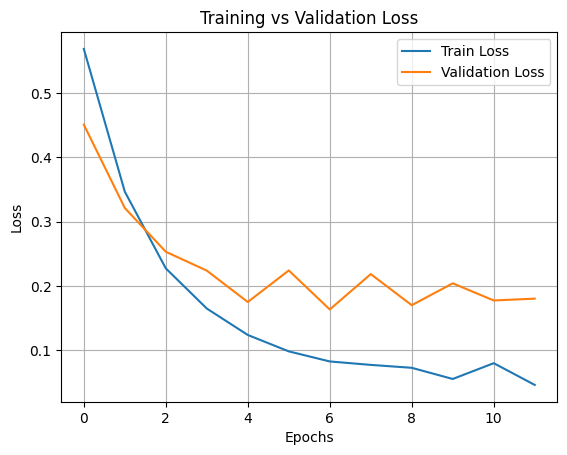

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


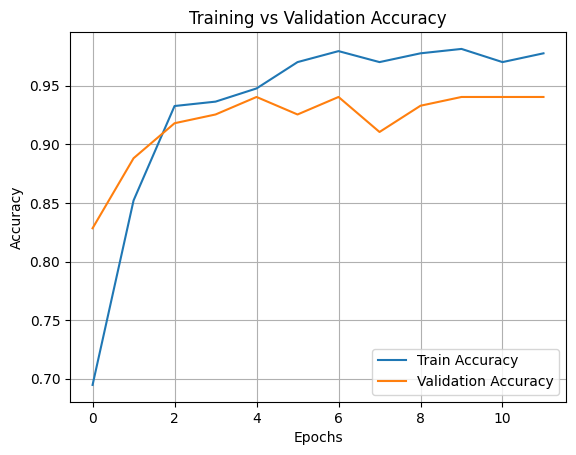

In [44]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


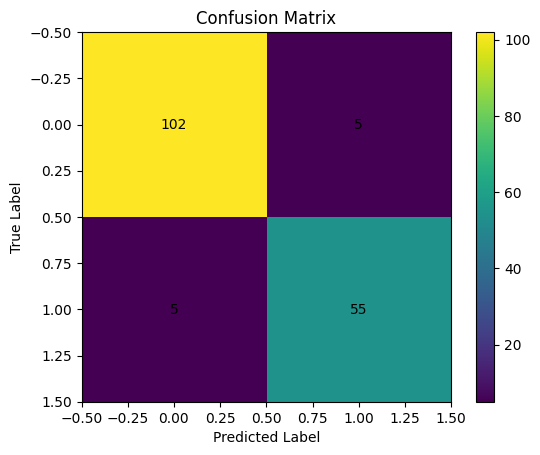

In [45]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.show()


6/6 [==============================] - 0s 4ms/step


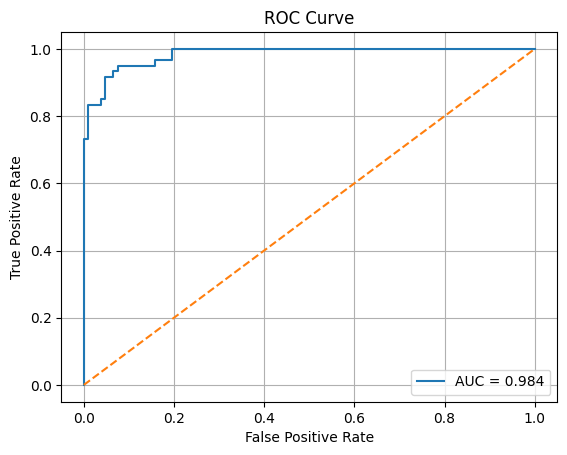

In [46]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test).ravel()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


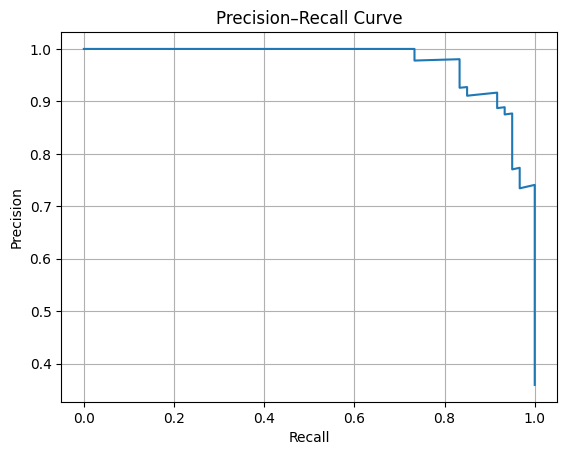

In [47]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()


# Retraining for backend

In [12]:
selected_features = [
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_pNN50",
    "HRV_LF",
    "HRV_HF",
    "HRV_LFHF",
    "HRV_SD1",
    "HRV_SD2"
]

X_df = data[selected_features]
y = data["label"]  # stress label (0/1)

In [13]:
y = data["label"]

# Convert 1/2 → 0/1
y = (y == 2).astype(int)

print(np.unique(y))  # should now print [0 1]

[0 1]


In [14]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

In [15]:
import numpy as np

TIME_STEPS = 30

def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y.values, TIME_STEPS)

print("X_seq shape:", X_seq.shape)

X_seq shape: (835, 30, 9)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(TIME_STEPS, len(selected_features))),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirecti  (None, 30, 128)           37888     
 onal)                                                           
                                                                 
 dropout_2 (Dropout)         (None, 30, 128)           0         
                                                                 
 bidirectional_3 (Bidirecti  (None, 64)                41216     
 onal)                                                           
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 79169 (309.25 KB)
Trainable params: 7916

In [18]:
print(np.unique(y))

[0 1]


In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
17/17 [==============================] - 3s 58ms/step - loss: 0.5941 - accuracy: 0.7097 - val_loss: 0.4635 - val_accuracy: 0.7836
Epoch 2/50
17/17 [==============================] - 0s 11ms/step - loss: 0.4224 - accuracy: 0.8127 - val_loss: 0.3474 - val_accuracy: 0.9030
Epoch 3/50
17/17 [==============================] - 0s 11ms/step - loss: 0.3121 - accuracy: 0.8989 - val_loss: 0.2654 - val_accuracy: 0.9030
Epoch 4/50
17/17 [==============================] - 0s 12ms/step - loss: 0.2138 - accuracy: 0.9288 - val_loss: 0.2165 - val_accuracy: 0.9179
Epoch 5/50
17/17 [==============================] - 0s 11ms/step - loss: 0.1771 - accuracy: 0.9288 - val_loss: 0.2220 - val_accuracy: 0.9104
Epoch 6/50
17/17 [==============================] - 0s 11ms/step - loss: 0.1809 - accuracy: 0.9307 - val_loss: 0.2311 - val_accuracy: 0.9104
Epoch 7/50
17/17 [==============================] - 0s 11ms/step - loss: 0.1439 - accuracy: 0.9457 - val_loss: 0.1797 - val_accuracy: 0.9328
Epoch 8/50
17

In [20]:
model.save("app/models/ecg_stress_lstm.keras")

In [21]:
import joblib

joblib.dump(scaler, "app/models/ecg_stress_scaler.pkl")

['app/models/ecg_stress_scaler.pkl']

In [22]:
joblib.dump(TIME_STEPS, "app/models/ecg_stress_time_steps.pkl")

['app/models/ecg_stress_time_steps.pkl']